# Propagation of KdV Solitons

The program propagates solitons of the Korteweg–De Vries equation and compares solitons for different velocity parameters c.

## Korteweg–De Vries Equation

The simulated partial differential equation is

\begin{equation}
\frac{\partial y}{\partial t} + 6y\frac{\partial y}{\partial x} + \frac{\partial^3 y}{\partial x^3}=0
\end{equation}

The analytical soliton solution is

\begin{equation}
y(x,t)=\frac{c}{2}\,\mathrm{sech}^2\left(\frac{\sqrt{c}}{2}(x-x_0-ct)\right)
\end{equation}

The equation is solved numerically with a **finite-difference method**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

## Analytical Soliton Solution

### Formula
\begin{equation}
y(x,t)=\frac{c}{2}\,\mathrm{sech}^2\left(\frac{\sqrt{c}}{2}(x-x_0-ct)\right)
\end{equation}

In [2]:
def sech(x):
    return 1/np.cosh(x)

# analytical solution of a KdV soliton at fixed time t
def KdVSoliton(x,t,c,x0,NG):
    y = 0.5*c*sech(0.5*np.sqrt(c)*(x[:NG]-x0-c*t))**2
    return y

## Parameters

In [3]:
L = 80                               # Length of the water line

NG = 801                             # Number of spatial grid points
dx = L/(NG-1)                        # Distance between two grid points
x = np.arange(NG)*dx

Tmax = 20.                           # maximum time
NT = 100001                          # number of time steps
dt = Tmax/(NT-1)                     # time step
t = np.arange(NT)*dt                 # time grid

## Prepare grids

In [4]:
y1 = np.zeros((NT,NG))
y2 = np.zeros((NT,NG))
y3 = np.zeros((NT,NG))
y4 = np.zeros((NT,NG))

## Initial Conditions for first velocity

In [5]:
# Initial condition: soliton with velocity c = 0.5
c = 0.5
y1[0,:] = KdVSoliton(x,0,c,10,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y1[1,:] = KdVSoliton(x,dt,c,10,NG)

## Solve PDE for first velocity

Finite difference update scheme:

\begin{equation}
y_x = y_{i+1}-y_{i-1}
\end{equation}

\begin{equation}
y_{xxx}=y_{i+2}-2y_{i+1}+2y_{i-1}-y_{i-2}
\end{equation}

\begin{equation}
y_j = y_{j-2}-\frac{dt}{dx}\left(6y_{j-1}y_x + \frac{y_{xxx}}{dx^2}\right)
\end{equation}

In [6]:
# Solve the PDE using the finite-difference method
# first velocity c = 0.5
for j in range(2, NT):

    yx = y1[j-1, 3:NG-1] - y1[j-1, 1:NG-3]

    yx3 = (
        y1[j-1, 4:NG]
        - 2*y1[j-1, 3:NG-1]
        + 2*y1[j-1, 1:NG-3]
        - y1[j-1, 0:NG-4])

    y1[j, 2:NG-2] = y1[j-2, 2:NG-2] - (dt/dx) * (6 * y1[j-1, 2:NG-2] * yx + yx3 / dx**2)

# Solve PDE for other velocities

## Initial Conditions and solve PDE for second velocity

In [7]:
# second velocity
# Initial condition: soliton with velocity c = 1.0
c = 1.0
y2[0,:] = KdVSoliton(x,0,c,10,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y2[1,:] = KdVSoliton(x,dt,c,10,NG)

# Solve the PDE using the finite-difference method
for j in range(2, NT):

    yx = y2[j-1, 3:NG-1] - y2[j-1, 1:NG-3]

    yx3 = (
        y2[j-1, 4:NG]
        - 2*y2[j-1, 3:NG-1]
        + 2*y2[j-1, 1:NG-3]
        - y2[j-1, 0:NG-4])

    y2[j, 2:NG-2] = y2[j-2, 2:NG-2] - (dt/dx) * (6 * y2[j-1, 2:NG-2] * yx + yx3 / dx**2)

## Initial Conditions and solve PDE for thrid velocity

In [8]:
# third velocity
# Initial condition: soliton with velocity c = 2.0
c = 2.0
y3[0,:] = KdVSoliton(x,0,c,10,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y3[1,:] = KdVSoliton(x,dt,c,10,NG)

# Solve the PDE using the finite-difference method
for j in range(2, NT):

    yx = y3[j-1, 3:NG-1] - y3[j-1, 1:NG-3]

    yx3 = (
        y3[j-1, 4:NG]
        - 2*y3[j-1, 3:NG-1]
        + 2*y3[j-1, 1:NG-3]
        - y3[j-1, 0:NG-4])

    y3[j, 2:NG-2] = y3[j-2, 2:NG-2] - (dt/dx) * (6 * y3[j-1, 2:NG-2] * yx + yx3 / dx**2)

## Initial Conditions and solve PDE for fourth velocity

In [9]:
# fourth velocity
# Initial condition: soliton with velocity c = 3.0
c = 3.0
y4[0,:] = KdVSoliton(x,0,c,10,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y4[1,:] = KdVSoliton(x,dt,c,10,NG)

# Solve the PDE using the finite-difference method
for j in range(2, NT):

    yx = y4[j-1, 3:NG-1] - y4[j-1, 1:NG-3]

    yx3 = (
        y4[j-1, 4:NG]
        - 2*y4[j-1, 3:NG-1]
        + 2*y4[j-1, 1:NG-3]
        - y4[j-1, 0:NG-4])

    y4[j, 2:NG-2] = y4[j-2, 2:NG-2] - (dt/dx) * (6 * y4[j-1, 2:NG-2] * yx + yx3 / dx**2)

## Visualization

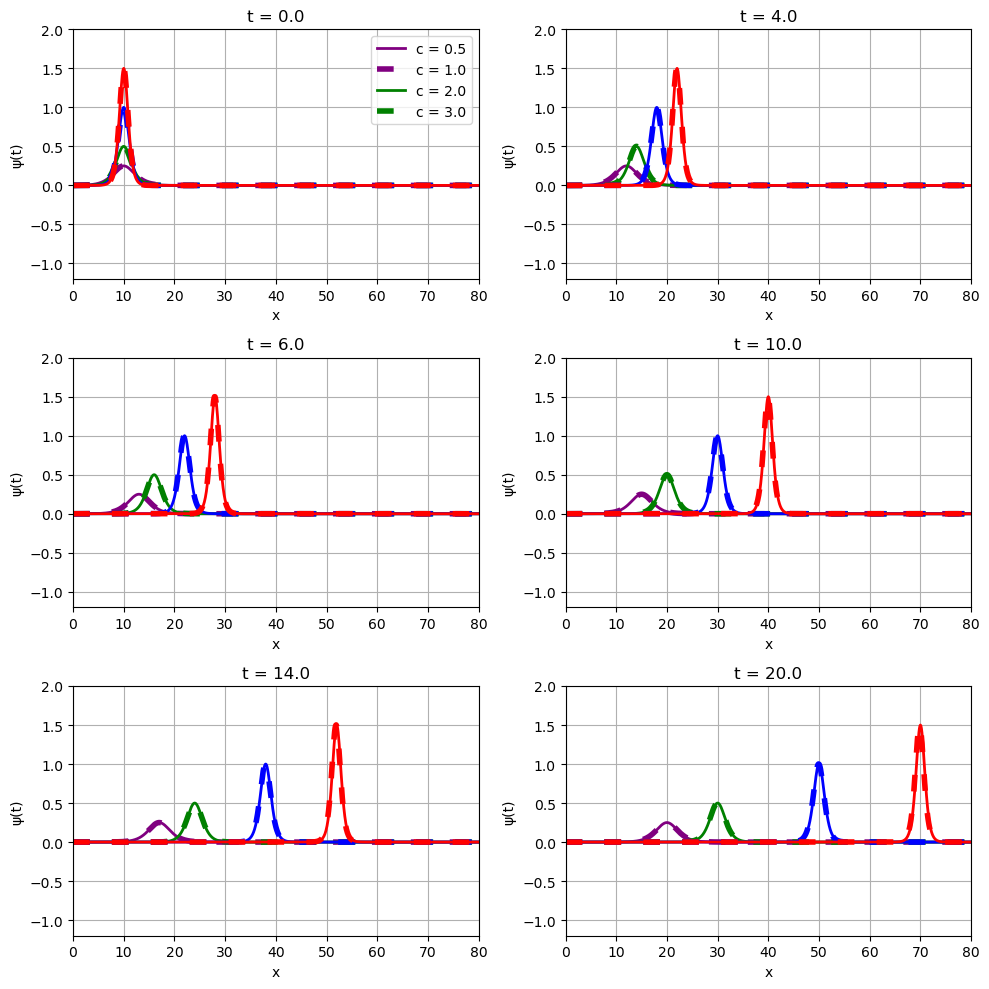

In [10]:
k = [0, 19999, 29999, 49999, 69999, 99999]

plt.figure(figsize=(10,10))

Colors = ['purple', 'green', 'blue', 'red']

for idx,i in enumerate(k):
    plt.subplot(3,2,idx+1)
    
    # Plot analytical and numerical solitons for each velocity
    # c = 0.5
    plt.plot(x, KdVSoliton(x, dt*i, 0.5, 10, NG), linewidth=2, color=Colors[0])
    line, = plt.plot(x, y1[i,:], linewidth=4, color=Colors[0])
    line.set_dashes([3,4])

    # c = 1.0
    plt.plot(x, KdVSoliton(x, dt*i, 1.0, 10, NG), linewidth=2, color=Colors[1])
    line, = plt.plot(x, y2[i,:], linewidth=4, color=Colors[1])
    line.set_dashes([3,4])

    # c = 2.0
    plt.plot(x, KdVSoliton(x, dt*i, 2.0, 10, NG), linewidth=2, color=Colors[2])
    line, = plt.plot(x, y3[i,:], linewidth=4, color=Colors[2])
    line.set_dashes([3,4])

    # c = 3.0
    plt.plot(x, KdVSoliton(x, dt*i, 3.0, 10, NG), linewidth=2, color=Colors[3])
    line, = plt.plot(x, y4[i,:], linewidth=4, color=Colors[3])
    line.set_dashes([3,4])
    
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), -1.2, 2])
    plt.xlabel('x')
    plt.ylabel('ψ(t)')

    if idx == 0:
        plt.legend(['c = 0.5','c = 1.0','c = 2.0','c = 3.0'], loc='upper right')
    
    titletext = f"t = {t[i]:.1f}"
    plt.title(titletext)

plt.tight_layout()
plt.show()